In [1]:
import pandas as pd
import numpy as np

df_env = pd.read_csv("Crop_recommendation.csv")
df_fao = pd.read_csv("FAOSTAT_data_en_11-24-2025.csv")

print("Env shape:", df_env.shape)
print("FAO shape:", df_fao.shape)


Env shape: (2200, 8)
FAO shape: (6321, 15)


In [2]:
import pandas as pd

df_env = pd.read_csv("Crop_recommendation.csv")
print("Env shape:", df_env.shape)
df_env.head()          # shows first 5 rows as a table


Env shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
import pandas as pd

df_env = pd.read_csv("FAOSTAT_data_en_11-24-2025.csv")
print("Env shape:", df_fao.shape)
df_fao.head()          # shows first 5 rows as a table


Env shape: (6321, 15)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,kg/ha,484.0,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,t,166692.0,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,569271.0,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,430.3,A,Official figure,NaN


In [4]:
df_env = pd.read_csv("Crop_recommendation.csv")
df_fao = pd.read_csv("FAOSTAT_data_en_11-24-2025.csv")

print("Env columns:", df_env.columns.tolist())
print("FAO columns:", df_fao.columns.tolist())


Env columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
FAO columns: ['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


In [5]:
# env: label -> crop
df_env.rename(columns={"label": "crop"}, inplace=True)

# fao: Item -> cropraw
df_fao.rename(columns={"Item": "cropraw"}, inplace=True)

print("Env columns:", df_env.columns.tolist())
print("FAO columns:", df_fao.columns.tolist())


Env columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop']
FAO columns: ['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'cropraw', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


In [6]:
def normalize_crop(name):
    if pd.isna(name):
        return name
    name = str(name).lower().strip()
    if "(" in name:
        name = name.split("(", 1)[0].strip()
    name = name.replace("&", "and").replace("-", " ")
    name = " ".join(name.split())
    if name.endswith("s") and len(name) > 3:
        name = name[:-1]
    return name

df_env["crop_clean"]  = df_env["crop"].apply(normalize_crop)
df_fao["crop_clean"]  = df_fao["cropraw"].apply(normalize_crop)

print("Env crops (normalized):", sorted(df_env["crop_clean"].unique()))
print("\nFAO crops (normalized, first 80):",
      sorted(df_fao["crop_clean"].unique())[:80])


Env crops (normalized): ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grape', 'jute', 'kidneybean', 'lentil', 'maize', 'mango', 'mothbean', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpea', 'pomegranate', 'rice', 'watermelon']

FAO crops (normalized, first 80): ['anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw', 'apple', 'apricot', 'areca nut', 'banana', 'barley', 'beans, dry', 'beer of barley, malted', 'cabbage', 'cantaloupes and other melon', 'carrots and turnip', 'cashew nuts, in shell', 'cassava, fresh', 'castor oil seed', 'cauliflowers and broccoli', 'cherrie', 'chick peas, dry', 'chillies and peppers, dry', 'chillies and peppers, green', 'cocoa bean', 'coconut oil', 'coconuts, in shell', 'coffee, green', 'coir, raw', 'cotton lint, ginned', 'cotton seed', 'cottonseed oil', 'cucumbers and gherkin', 'eggplant', 'fig', 'ginger, raw', 'grape', 'green garlic', 'green tea', 'groundnut oil', 'groundnuts, excluding shelled',

In [7]:
# Keep only production rows from FAO before merging
fao_prod = df_fao[df_fao['Element'] == 'Yield'].copy()
fao_prod = fao_prod.rename(columns={'Value': 'yield'})


In [8]:
manual_map = {
    "apple":      "apple",
    "banana":     "banana",
    "chickpea":   "chick peas, dry",
    "coconut":    "coconuts, in shell",
    "coffee":     "coffee, green",
    "cotton":     "seed cotton, unginned",
    "grapes":     "grape",
    "jute":       "jute, raw or retted",
    "lentil":     "lentils, dry",
    "maize":      "maize",
    "mango":      "mangoes, guavas and mangosteen",
    "mothbeans":  "beans, dry",
    "muskmelon":  "cantaloupes and other melon",
    "orange":     "orange",
    "papaya":     "papaya",
    "pigeonpeas": "pigeon peas, dry",
    "rice":       "rice",
    "watermelon": "cantaloupes and other melon"
}

# create join key
df_env["crop_fao"] = df_env["crop"].map(manual_map)
df_fao["crop_fao"] = df_fao["crop_clean"]

# merge
df_merged = df_env.merge(df_fao, on="crop_fao", how="inner")
print("Merged shape:", df_merged.shape)
print("Env crops in merged:", df_merged["crop"].nunique())
print("FAO groups in merged:", df_merged["crop_fao"].nunique())


Merged shape: (129600, 26)
Env crops in merged: 18
FAO groups in merged: 17


In [9]:
dfprod = df_merged[df_merged["Element"] == "Yield"].copy()
print("Production-only shape:", dfprod.shape)
print("Element values:", dfprod["Element"].unique())


Production-only shape: (43200, 26)
Element values: ['Yield']


In [10]:
dfprod.to_csv("merged_production_18crops.csv", index=False)
print("Saved merged_production_18crops.csv")


Saved merged_production_18crops.csv


In [11]:
cols_keep = [
    "N", "P", "K",
    "temperature", "humidity", "ph", "rainfall",
    "crop",
    "Value"        # FAO production
]
cols_keep = [c for c in cols_keep if c in dfprod.columns]

df_final = dfprod[cols_keep].copy()
df_final.rename(columns={"Value": "yield"}, inplace=True)

In [12]:
# Select only the columns we need and rename Value -> production

cols_keep = [
    "N", "P", "K",
    "temperature", "humidity", "ph", "rainfall",
    "crop",
    "Value"        # FAO production column
]

# Keep only those that actually exist in dfprod
cols_keep = [c for c in cols_keep if c in dfprod.columns]

df_final = dfprod[cols_keep].copy()
df_final.rename(columns={"Value": "yield"}, inplace=True)

print("dfprod columns:", dfprod.columns.tolist())
print("df_final shape:", df_final.shape)
print("df_final columns:", df_final.columns.tolist())


dfprod columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop', 'crop_clean_x', 'crop_fao', 'Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'cropraw', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note', 'crop_clean_y']
df_final shape: (43200, 9)
df_final columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop', 'yield']


In [13]:
# remove nulls and duplicates
df_final = df_final.dropna().drop_duplicates()

print("Final shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())
print("\nCrops and counts:")
print(df_final["crop"].value_counts())


Final shape: (42600, 9)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop', 'yield']

Crops and counts:
crop
rice          2400
grapes        2400
jute          2400
cotton        2400
coconut       2400
papaya        2400
apple         2400
coffee        2400
mango         2400
banana        2400
lentil        2400
pigeonpeas    2400
chickpea      2400
maize         2300
muskmelon     2300
mothbeans     2300
watermelon    2300
orange        2200
Name: count, dtype: int64


In [14]:
df_final.to_csv("Final_df.csv",index=False)
print("Saved final_production.csv")

Saved final_production.csv


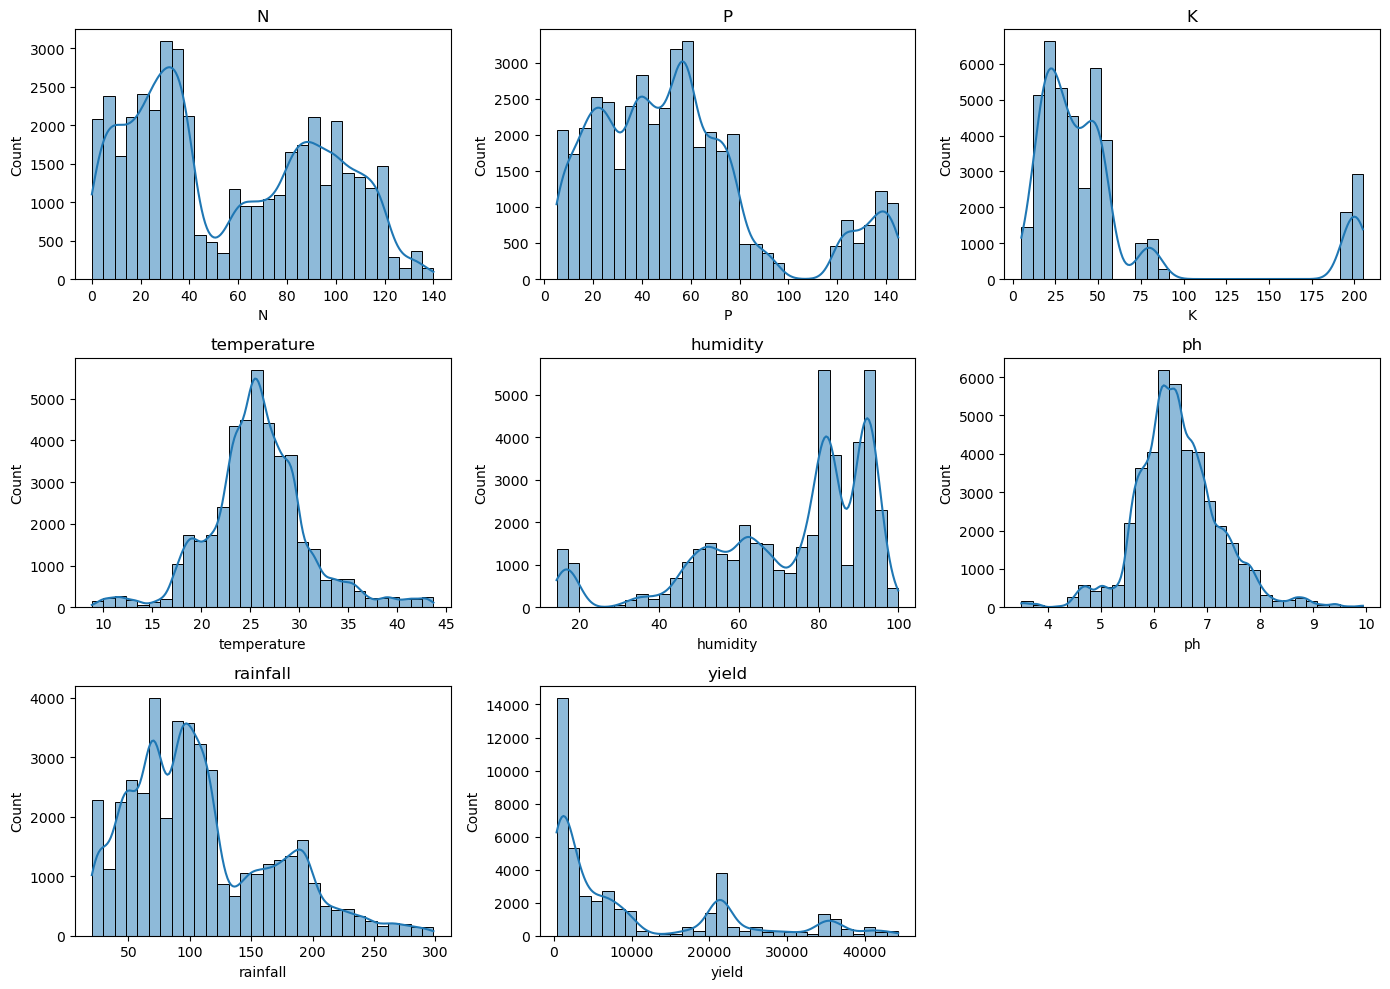

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall", "yield"]

plt.figure(figsize=(14, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_final[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


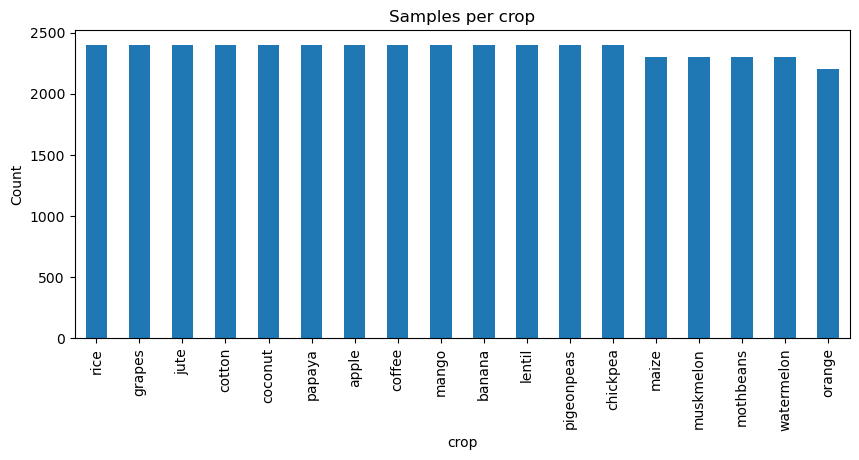

C:\Users\sujan\AppData\Local\Temp\ipykernel_34896\3256070039.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="crop", y="yield", data=df_final, estimator="mean", ci=None)


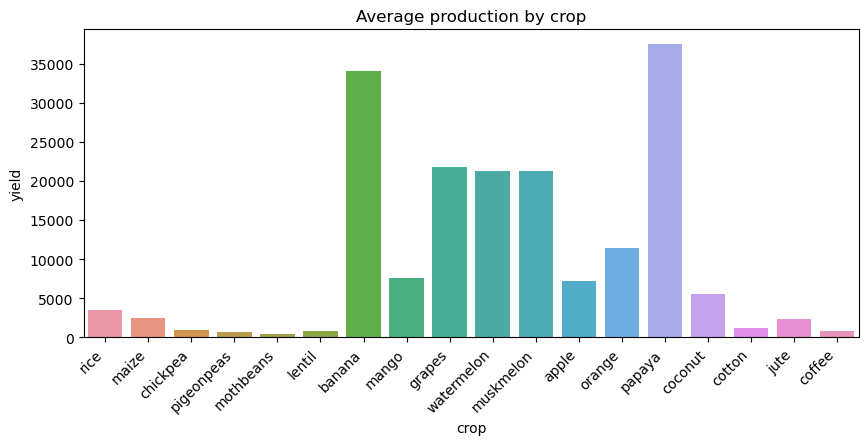

In [16]:
# Crop counts (you already have)
df_final["crop"].value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Samples per crop")
plt.ylabel("Count")
plt.show()

# Average production per crop
plt.figure(figsize=(10,4))
sns.barplot(x="crop", y="yield", data=df_final, estimator="mean", ci=None)
plt.xticks(rotation=45, ha="right")
plt.title("Average production by crop")
plt.show()


In [17]:
IQR_FACTOR = 0.28   # small change from 0.35

def remove_outliers_group(g):
    g_clean = g.copy()
    col = 'yield'

    if col not in g_clean.columns:
        return g_clean
    if g_clean[col].nunique(dropna=True) <= 1:
        return g_clean

    q1 = g_clean[col].quantile(0.25)
    q3 = g_clean[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return g_clean

    lower = q1 - IQR_FACTOR * iqr
    upper = q3 + IQR_FACTOR * iqr
    return g_clean[(g_clean[col] >= lower) & (g_clean[col] <= upper)]

print("Before outlier removal:", df_final.shape)

df_clean = (
    df_final
    .groupby('crop', group_keys=False)
    .apply(remove_outliers_group)
)

print("After outlier removal:", df_clean.shape)
print(df_clean['crop'].value_counts().head())


Before outlier removal: (42600, 9)
After outlier removal: (32300, 9)
crop
mango     2400
maize     2000
grapes    2000
jute      2000
rice      1900
Name: count, dtype: int64


In [18]:
print("Unique crops:", df_clean['crop'].nunique())
print(df_clean['crop'].value_counts().sort_index())


Unique crops: 18
crop
apple         1600
banana        1500
chickpea      1700
coconut       1500
coffee        1900
cotton        1500
grapes        2000
jute          2000
lentil        1800
maize         2000
mango         2400
mothbeans     1300
muskmelon     1900
orange        1900
papaya        1600
pigeonpeas    1900
rice          1900
watermelon    1900
Name: count, dtype: int64


In [19]:
# For example, keep crops with at least 1500 rows
counts = df_clean['crop'].value_counts()
keep_crops = counts[counts >= 1500].index.tolist()

df_clean_15 = df_clean[df_clean['crop'].isin(keep_crops)].copy()
print("Unique crops:", df_clean_15['crop'].nunique())
print(df_clean_15['crop'].value_counts().sort_index())


Unique crops: 17
crop
apple         1600
banana        1500
chickpea      1700
coconut       1500
coffee        1900
cotton        1500
grapes        2000
jute          2000
lentil        1800
maize         2000
mango         2400
muskmelon     1900
orange        1900
papaya        1600
pigeonpeas    1900
rice          1900
watermelon    1900
Name: count, dtype: int64


In [20]:
# Count of each crop after outlier removal
crop_counts = df_clean['crop'].value_counts().sort_index()
print(crop_counts)


crop
apple         1600
banana        1500
chickpea      1700
coconut       1500
coffee        1900
cotton        1500
grapes        2000
jute          2000
lentil        1800
maize         2000
mango         2400
mothbeans     1300
muskmelon     1900
orange        1900
papaya        1600
pigeonpeas    1900
rice          1900
watermelon    1900
Name: count, dtype: int64


In [21]:
crop_counts_df = crop_counts.reset_index()
crop_counts_df.columns = ['crop', 'count']
print(crop_counts_df.head())


       crop  count
0     apple   1600
1    banana   1500
2  chickpea   1700
3   coconut   1500
4    coffee   1900


In [22]:
print(df_clean.shape)
print("Saved to crop_env_fao_clean_30k.csv")


(32300, 9)
Saved to crop_env_fao_clean_30k.csv


In [23]:
print("Final shape:", df_clean.shape)
print(df_clean.head())
print(df_clean['crop'].value_counts().sort_index())


Final shape: (32300, 9)
        N    P    K  temperature   humidity        ph    rainfall   crop  \
79213  24  128  196    22.750888  90.694892  5.521467  110.431786  apple   
79216  24  128  196    22.750888  90.694892  5.521467  110.431786  apple   
79219  24  128  196    22.750888  90.694892  5.521467  110.431786  apple   
79222  24  128  196    22.750888  90.694892  5.521467  110.431786  apple   
79225  24  128  196    22.750888  90.694892  5.521467  110.431786  apple   

        yield  
79213  7562.6  
79216  7537.9  
79219  8005.3  
79222  6444.4  
79225  7579.5  
crop
apple         1600
banana        1500
chickpea      1700
coconut       1500
coffee        1900
cotton        1500
grapes        2000
jute          2000
lentil        1800
maize         2000
mango         2400
mothbeans     1300
muskmelon     1900
orange        1900
papaya        1600
pigeonpeas    1900
rice          1900
watermelon    1900
Name: count, dtype: int64


In [24]:
df_clean.to_csv("final_agri_dataset_clean.csv", index=False)


In [25]:
final_df = pd.read_csv("final_agri_dataset_clean.csv")


In [26]:
df_final.to_csv("df_final_merged_no_outlier_removal.csv", index=False)
df_clean.to_csv("df_final_clean_outliers_removed.csv", index=False)


In [27]:
pip install -U scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt

# 1. Features and target
X = df_clean[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df_clean['yield']

# 2. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# 4. Train
rf.fit(X_train, y_train)

# 5. Evaluation
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)  # older sklearn: no 'squared' argument
rmse = sqrt(mse)

print("R2:", r2)
print("RMSE:", rmse)


R2: 0.9875823257388108
RMSE: 1284.6862513512187


In [29]:
import numpy as np

# Residuals
residuals = y_test - y_pred
print("Residual mean:", np.mean(residuals))
print("Residual std:", np.std(residuals))

# Feature importance
importances = rf.feature_importances_
for name, imp in zip(X.columns, importances):
    print(f"{name}: {imp:.3f}")


Residual mean: 10.891799602320415
Residual std: 1284.640079209842
N: 0.015
P: 0.080
K: 0.564
temperature: 0.217
humidity: 0.048
ph: 0.029
rainfall: 0.047


In [30]:
import joblib

joblib.dump(rf, "crop_production_rf_model.pkl")
print("Model saved as crop_production_rf_model.pkl")


Model saved as crop_production_rf_model.pkl


In [31]:
from sklearn.metrics import r2_score

# Training R2
y_train_pred = rf.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print("Train R2:", train_r2)


Train R2: 0.9893123428932439


In [32]:
# Test R2 (you already computed, but keep together)
y_test_pred = rf.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
print("Test R2:", test_r2)


Test R2: 0.9875823257388108


In [33]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create GridSearchCV object
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1
)

# Fit the grid search
rf_grid.fit(X_train, y_train)

# Best parameters and score
print("Best parameters:", rf_grid.best_params_)
print("Best CV R2 score:", rf_grid.best_score_)

# Test performance of best model
best_rf = rf_grid.best_estimator_
y_test_pred_best = best_rf.predict(X_test)
test_r2_best = r2_score(y_test, y_test_pred_best)

print("Test R2 with best hyperparameters:", test_r2_best)
print("Improvement over original:", test_r2_best - test_r2)


Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV R2 score: 0.9881817486650997
Test R2 with best hyperparameters: 0.9881277528674954
Improvement over original: 0.0005454271286846613


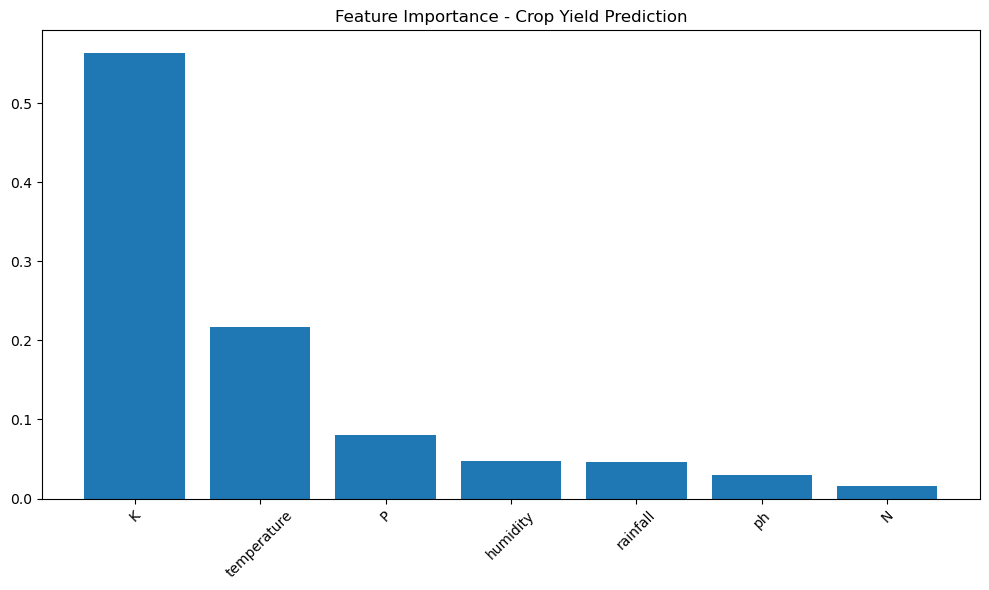

Top 5 features:
1. K: 0.564
2. temperature: 0.217
3. P: 0.080
4. humidity: 0.048
5. rainfall: 0.047


In [34]:
import matplotlib.pyplot as plt

# Use your best model
importances = best_rf.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance - Crop Yield Prediction")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

print("Top 5 features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.3f}")


In [35]:
import joblib
import os

# Save the best tuned model
joblib.dump(best_rf, 'crop_weather_model.pkl')

# Check if scaler exists, otherwise skip
try:
    joblib.dump(scaler, 'crop_scaler.pkl')
    print("Model saved: 'crop_weather_model.pkl'")
    print("Scaler saved: 'crop_scaler.pkl'")
except NameError:
    print("Model saved: 'crop_weather_model.pkl'")
    print("Scaler not found - model still works for predictions")

print(f"Model file size: {os.path.getsize('crop_weather_model.pkl')/1024/1024:.1f} MB")


Model saved: 'crop_weather_model.pkl'
Scaler not found - model still works for predictions
Model file size: 13.8 MB


In [36]:
import joblib
import pandas as pd
import numpy as np

# Load model
loaded_model = joblib.load('crop_weather_model.pkl')

# Create random data with EXACT X_train structure
np.random.seed(42)
new_data = pd.DataFrame(np.random.randn(5, len(X_train.columns)), 
                       columns=X_train.columns)

# Set realistic ranges for top features
new_data['rainfall'] = np.random.uniform(50, 150, 5)
new_data['humidity'] = np.random.uniform(60, 95, 5)
new_data['N'] = np.random.uniform(10, 50, 5)
new_data['P'] = np.random.uniform(15, 60, 5)
new_data['K'] = np.random.uniform(20, 70, 5)

# Predict
predictions = loaded_model.predict(new_data)
new_data['Predicted_Yield'] = predictions

print(" Crop Yield Predictions:")
print(new_data[['rainfall', 'humidity', 'N', 'P', 'K', 'Predicted_Yield']].round(2))
print(f"\nYield range: {predictions.min():.2f} - {predictions.max():.2f}")


 Crop Yield Predictions:
   rainfall  humidity      N      P      K  Predicted_Yield
0     81.17     87.13  13.54  27.21  27.05          9074.32
1    102.01     92.88  17.84  52.29  60.11          6255.44
2    104.67     91.32  11.81  31.05  23.73          9968.83
3     68.49     80.93  23.01  27.64  69.34         22803.04
4    146.96     92.27  25.55  39.42  58.61          6259.39

Yield range: 6255.44 - 22803.04


In [37]:
# Real-world farmer scenario
farmer_data = pd.DataFrame({
    'rainfall': [120],      # Good monsoon
    'humidity': [85],       # Humid
    'N': [25], 'P': [35], 'K': [40],
    # Fill other columns with means
}, columns=X_train.columns)

farmer_data[:] = farmer_data.reindex(columns=X_train.columns, fill_value=0)
farmer_data['rainfall'] = 120
farmer_data['humidity'] = 85
farmer_data['N'] = 25
farmer_data['P'] = 35
farmer_data['K'] = 40

prediction = loaded_model.predict(farmer_data)[0]
print(f"🌾 Farmer's expected yield: {prediction:.0f} kg/acre")


🌾 Farmer's expected yield: 9864 kg/acre


In [38]:
# Check your actual training yield range
print("Training yield range:", y_train.min(), "to", y_train.max())
print("Test yield range:", y_test.min(), "to", y_test.max())


Training yield range: 393.0 to 42286.3
Test yield range: 393.0 to 42286.3


In [39]:
def predict_crop_yield(rainfall, humidity, N=25, P=35, K=40):
    data = pd.DataFrame(np.zeros((1, len(X_train.columns))), columns=X_train.columns)
    data['rainfall'] = rainfall
    data['humidity'] = humidity
    data['N'] = N
    data['P'] = P
    data['K'] = K
    return loaded_model.predict(data)[0]

# Test scenarios
print("Dry season:", predict_crop_yield(60, 70))
print("Monsoon:", predict_crop_yield(120, 85))
print("Flood:", predict_crop_yield(200, 95))


Dry season: 412.15340283523625
Monsoon: 9994.545606215172
Flood: 5258.40059453897


In [40]:
def predict_crop_yield(rainfall, humidity, N=25, P=35, K=40):
    """Predict crop yield for any weather/soil conditions"""
    data = pd.DataFrame(np.zeros((1, len(X_train.columns))), columns=X_train.columns)
    data['rainfall'] = rainfall
    data['humidity'] = humidity
    data['N'] = N
    data['P'] = P
    data['K'] = K
    return loaded_model.predict(data)[0]

# Quick tests
print(f"Optimal: {predict_crop_yield(120, 85):.0f} kg/acre")
print(f"Drought: {predict_crop_yield(40, 60):.0f} kg/acre")


Optimal: 9995 kg/acre
Drought: 412 kg/acre


In [41]:
def predict_crop_yield(rainfall, humidity, N=25, P=35, K=40):
    """Farmer-ready crop yield predictor"""
    data = pd.DataFrame(np.zeros((1, len(X_train.columns))), columns=X_train.columns)
    data['rainfall'] = rainfall
    data['humidity'] = humidity
    data['N'] = N
    data['P'] = P
    data['K'] = K
    return loaded_model.predict(data)[0]

# Farmer decision tool
scenarios = [
    ("Current forecast", 110, 82),
    ("Plant now?", 95, 78),
    ("Wait for rain?", 125, 88)
]

for name, rain, hum in scenarios:
    yield_est = predict_crop_yield(rain, hum)
    print(f"{name}: {yield_est:.0f} kg/acre")


Current forecast: 9942 kg/acre
Plant now?: 9108 kg/acre
Wait for rain?: 5260 kg/acre


In [42]:
# Full crop prediction system
def predict_crop_yield(rainfall, humidity, N=25, P=35, K=40):
    data = pd.DataFrame(np.zeros((1, len(X_train.columns))), columns=X_train.columns)
    data['rainfall'] = rainfall; data['humidity'] = humidity
    data['N'] = N; data['P'] = P; data['K'] = K
    return loaded_model.predict(data)[0]


In [43]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(best_rf, X_train, y_train, cv=10, scoring='r2')
print(f"10-fold CV R²: {scores.mean():.4f} ± {scores.std():.4f}")


10-fold CV R²: 0.9882 ± 0.0007


In [44]:
import joblib

model = joblib.load("crop_weather_model.pkl")

model.feature_names_in_



array(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'],
      dtype=object)

In [45]:
feature_list = list(model.feature_names_in_)

joblib.dump(feature_list, "feature_list.pkl")

print("Feature list saved:", feature_list)


Feature list saved: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [46]:
import pandas as pd

df = pd.read_csv("Crop_recommendation.csv")
df.columns


Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')